In [1]:
import cmocean
import numpy as np 
import xarray as xr
import pandas as pd 
import seaborn as sns
import cartopy.crs as ccrs
import statsmodels.api as sm
import matplotlib.pyplot as plt
from IPython.display import HTML
from scipy.stats import linregress 
from nemo_cookbook import NEMODataTree 
from matplotlib.patches import Rectangle
from OceanDataStore import OceanDataCatalog 
from matplotlib.animation import FuncAnimation

In [2]:
## Freshwater budget details:
    # Box region: 25-35W, 52-58N
    # Model: 1/4 degree
    # Desnity of freshwater: 1000 Kg/m3
    # Assume constant mixed layer salinity
    # Consider July-July changes 

In [3]:
# Open monthly means 

catalog = OceanDataCatalog(catalog_name="noc-model-stac")
catalog.search(collection='noc-npd-era5', standard_name='sea_surface_temperature')
ds1 = catalog.open_dataset(id=catalog.Items[3].id,
                          start_datetime='1990-01',
                          end_datetime='2024-12')
catalog.search(collection='noc-npd-era5', item_name='domain_cfg')
config = catalog.open_dataset(id=catalog.Items[1].id)

# Merge into a data tree
datasets = {"parent": {"domain": config, "gridT": ds1}}
dt_global = NEMODataTree.from_datasets(datasets = datasets)

# Clip to North Atlantic 
bbox = (-35.0, -25.0, 52.0, 58.0)
dt_clipped = dt_global.clip_grid(grid="gridT", bbox=bbox)

# Add lat and lon as co-ordinates
dt = dt_clipped.add_geoindex(grid="gridT")


            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1y
              Title: eORCA1 ERA5v1 NPD T1y Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics annual mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca1-era5v1/gn/T1m
              Title: eORCA1 ERA5v1 NPD T1m Icechunk repository
              Description: Icechunk repository containing eORCA1 ERA5v1 NPD global ocean physics monthly mean outputs defined at T-points.
              Platform: gn
              Start Date: 1976-01-01T00:00:00Z
              End Date: 2025-07-31T00:00:00Z
            

            * Item ID: noc-npd-era5/npd-eorca025-era5v1/gn/T1y_3d
              Title: eORCA025 ERA5v1 NPD T1y_3d Icechunk repository
              Description: Icechunk repository containing eORCA025 ERA5v1 

In [4]:
dt['gridT']['Freshwater Content'] = ((34.8 - dt['gridT']['sos_abs'])/34.8) * dt['gridT']['somxl010']
FC_ts = (dt.integral(grid='gridT', var='Freshwater Content', dims=['i', 'j']))
FC_ts_july = FC_ts.where(FC_ts['time_counter'].dt.month == 7, drop = True)
deltaFC = FC_ts_july.diff(dim='time_counter').compute()


In [8]:
FC = FC_ts_july.isel(time_counter = slice(1, None)).compute()

In [6]:
surface_flux = ((-dt.integral(grid='gridT', var='sowaflup', dims=['i', 'j'])).isel(time_counter = slice(6, 414)))/1000 

In [7]:
seconds_in_month = surface_flux['time_counter'].dt.days_in_month * 24 * 60 * 60
Q_Jpermonth = surface_flux * seconds_in_month

In [8]:
Integrated_Q = Q_Jpermonth.coarsen(time_counter=12).sum()


In [9]:
new_times = np.array([f'{y}-07-16T12:00:00.000000000' for y in range(1991, 2025)], dtype='datetime64[ns]')
Integrated_Q = Integrated_Q.assign_coords(time_counter=new_times)


In [10]:
deltaFC.to_netcdf('deltaFC_again.nc')
Integrated_Q.to_netcdf('integrated_surface_flux_again.nc')
FC.to_netcdf('July_FC.nc')

In [32]:
# Start from here 

FC = xr.open_dataset('July_FC.nc')['Freshwater Content']
deltaFC = xr.open_dataset('deltaFC_again.nc')['Freshwater Content']
surface_flux = xr.open_dataset('integrated_surface_flux_again.nc')['__xarray_dataarray_variable__']
MLD = xr.open_dataset('integrated_MLD.nc')['somxl010']
SSTs = xr.open_dataset('Monthly_SSTs.nc')['tos_con']
SSSs = xr.open_dataset('Monthly_SSSs.nc')['sos_abs']

In [33]:
new_times = np.array([f'{y}-07-16T12:00:00.000000000' for y in range(1991, 2025)], dtype='datetime64[ns]')

MLDjuly = MLD.where(MLD['time_counter'].dt.month == 7, drop = True)
MLDjuly = MLDjuly.isel(time_counter = slice(1, None))
MLDjuly = MLDjuly.assign_coords(time_counter=new_times)

SSTjuly = SSTs.where(SSTs['time_counter'].dt.month == 7, drop = True)
SSTjuly = SSTjuly.isel(time_counter = slice(1, None))
SSTjuly = SSTjuly.assign_coords(time_counter=new_times)

SSSjuly = SSSs.where(SSSs['time_counter'].dt.month == 7, drop = True)
SSSjuly = SSSjuly.isel(time_counter = slice(1, None))
SSSjuly = SSSjuly.assign_coords(time_counter=new_times)

In [34]:
# Calculate advective term and ratios 

residuals = deltaFC - surface_flux
magnitude_ratios = abs(surface_flux) / abs(residuals)
heatflux_contribution = surface_flux / deltaFC

In [35]:
FC.values

array([ 4.82105237e+10,  1.10579568e+10, -1.96470329e+10,  1.69759000e+10,
        2.87911413e+08, -3.57040988e+10, -6.05947064e+10, -7.55559509e+10,
       -3.37271272e+10, -2.42506951e+09, -1.31359167e+10, -2.48788942e+10,
       -2.50796390e+10,  8.05653654e+09,  1.07069264e+10,  3.26071402e+08,
        2.56501100e+08,  1.85734831e+09,  1.99849692e+10,  4.51209685e+10,
        1.38481068e+10,  1.92254549e+10,  4.81876829e+10,  1.75758921e+10,
        1.43131191e+10,  2.91027958e+10,  5.67759508e+10,  3.64275323e+10,
        3.16686189e+10,  1.02205481e+10,  4.00354000e+10,  2.27621521e+10,
        2.52869051e+10,  9.16195737e+09])

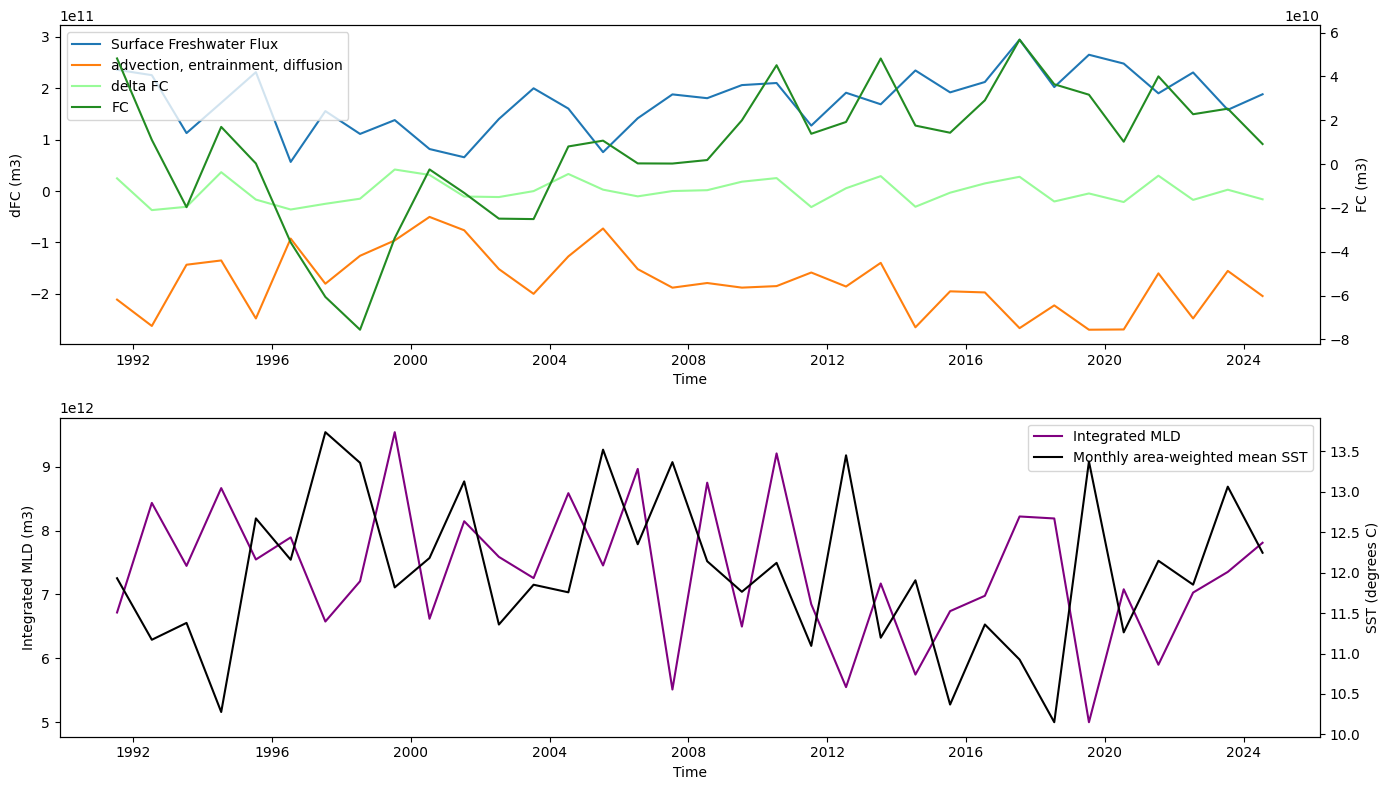

In [46]:
# Surface heat flux vs Advection vs dH/dt 

fig, ax = plt.subplots(2, 1, figsize = (14, 8))
ax1 = ax[0]
ax2 = ax1.twinx()
ax3 = ax[1]
ax4 = ax3.twinx()

l1 = ax1.plot(surface_flux['time_counter'], surface_flux, label = 'Surface Freshwater Flux')
l2 = ax1.plot(residuals['time_counter'], residuals, label = 'advection, entrainment, diffusion')
l3 = ax1.plot(deltaFC['time_counter'], deltaFC, color = '#98FB98', label = 'delta FC')
l4 = ax2.plot(FC['time_counter'], FC, color = '#228B22', label = 'FC')
lines1 = l1 + l2 + l3 + l4
labels1 = [l.get_label() for l in lines1]

ax1.legend(lines1, labels1, loc = 'best')
ax1.set_xlabel('Time')
ax1.set_ylabel('dFC (m3)')
ax2.set_ylabel('FC (m3)')

l5 = ax3.plot(MLDjuly['time_counter'], MLDjuly, label = 'Integrated MLD', color = 'purple')
l6 = ax4.plot(SSTjuly['time_counter'], SSTjuly, label = 'Monthly area-weighted mean SST', color = 'k')
lines2 = l5 + l6
labels2 = [l.get_label() for l in lines2]

ax3.legend(lines2, labels2, loc='best')
ax3.set_xlabel('Time')
ax3.set_ylabel('Integrated MLD (m3)')
ax4.set_ylabel('SST (degrees C)')


plt.tight_layout()
plt.show()

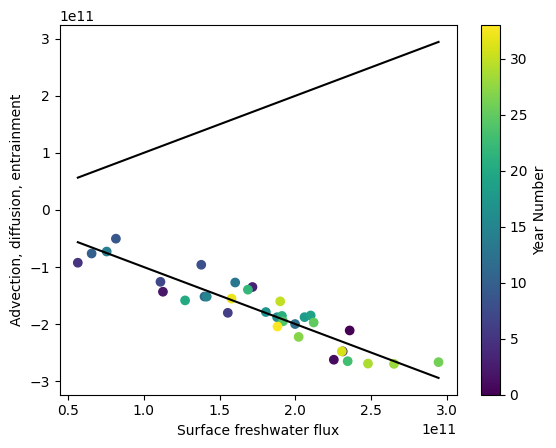

In [21]:
# Josey and Sinha Plot
progression = np.arange(len(surface_flux.values))
fig, ax = plt.subplots()

plt.scatter(surface_flux.values, residuals.values, c = progression, cmap = 'viridis')
plt.xlabel('Surface freshwater flux')
plt.ylabel('Advection, diffusion, entrainment')

xmin = surface_flux.min().item()
xmax = surface_flux.max().item()
x = np.linspace(xmin, xmax, 100)
plt.plot(x, x, color = 'k')
plt.plot(x, -x, color = 'k')
plt.colorbar(ax = ax, label = ('Year Number'))

plt.show()

In [22]:
dt['gridT']

<xarray.DataTree 'gridT'>
Group: /gridT
    Dimensions:                (time_counter: 420, axis_nbounds: 2, j: 37, i: 38,
                                k: 75)
    Coordinates:
      * j                      (j) int64 296B 926 927 928 929 ... 959 960 961 962
      * i                      (i) int64 304B 1011 1012 1013 1014 ... 1046 1047 1048
      * k                      (k) int64 600B 1 2 3 4 5 6 7 ... 69 70 71 72 73 74 75
        time_centered          (time_counter) datetime64[ns] 3kB dask.array<chunksize=(1,), meta=np.ndarray>
      * gphit                  (j, i) float64 11kB 52.07 52.07 52.08 ... 57.98 57.98
      * glamt                  (j, i) float64 11kB -34.87 -34.6 ... -25.31 -25.03
    Inherited coordinates:
      * time_counter           (time_counter) datetime64[ns] 3kB 1990-01-16T12:00...
    Dimensions without coordinates: axis_nbounds
    Data variables: (12/58)
        berg_latent_heat_flux  (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        empmr                  (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        ficeberg               (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        evs                    (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        hfempds                (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        fsitherm               (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
        ...                     ...
        e2t                    (j, i) float64 11kB dask.array<chunksize=(37, 38), meta=np.ndarray>
        top_level              (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
        bottom_level           (j, i) int32 6kB dask.array<chunksize=(37, 38), meta=np.ndarray>
        tmask                  (k, j, i) float64 844kB 1.0 1.0 1.0 ... 0.0 0.0 0.0
        tmaskutil              (j, i) float64 11kB 1.0 1.0 1.0 1.0 ... 1.0 1.0 1.0
        Freshwater Content     (time_counter, j, i) float32 2MB dask.array<chunksize=(1, 37, 38), meta=np.ndarray>
    Indexes:
      ┌ gphit    NDPointIndex (SklearnGeoBallTreeAdapter)
      └ glamt
    Attributes:
        nftype:   None
        iperio:   False